# Intro

* How to import and use the tokenizer from OpenAI
* More about tokenization schemes, including spaces and special characters

* Tokens are characters, subwords and words
* Non-normal distribution of token lengths
* No need to process or split text

# Install

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

We need to install the tik-token library to get OpenAI's tokenizer

In [3]:
!pip -q install tiktoken
import tiktoken

# Tokenizer

In [4]:
# GPT-4's tokenizer
tokenizer = tiktoken.get_encoding('cl100k_base')
dir(tokenizer)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_core_bpe',
 '_encode_bytes',
 '_encode_only_native_bpe',
 '_encode_single_piece',
 '_mergeable_ranks',
 '_pat_str',
 '_special_tokens',
 'decode',
 'decode_batch',
 'decode_bytes',
 'decode_bytes_batch',
 'decode_single_token_bytes',
 'decode_tokens_bytes',
 'decode_with_offsets',
 'encode',
 'encode_batch',
 'encode_ordinary',
 'encode_ordinary_batch',
 'encode_single_token',
 'encode_to_numpy',
 'encode_with_unstable',
 'eot_token',
 'is_special_token',
 'max_token_value',
 'n_vocab',
 'name',
 'special_tokens_set',
 'token_byte_values']

In [6]:
tokenizer??

In [7]:
# vocab size
tokenizer.n_vocab

100277

In [8]:
tokenizer.decode([tokenizer.eot_token])

'<|endoftext|>'

In [10]:
# not all tokens are valid, e.g.
print(tokenizer.n_vocab)
# tokenizer.decode([100261])

100277


# Explore some tokens

In [24]:
tokenizer.decode([513])

' se'

In [11]:
for i in range(1000, 1050):
  print(f'{i} = {tokenizer.decode([i])}')

1000 = indow
1001 = lement
1002 = pect
1003 = ash
1004 = [i
1005 =  use
1006 = .F
1007 = pec
1008 =  ad
1009 = ove
1010 = ception
1011 = ength
1012 = include
1013 = ader
1014 =                            
1015 = atus
1016 = Th
1017 = itle
1018 = rit
1019 = void
1020 = ().
1021 = (

1022 =  off
1023 =  other
1024 =  &&
1025 = ';

1026 = ms
1027 =  been
1028 =  te
1029 = ml
1030 = co
1031 = nc
1032 = 13
1033 = ervice
1034 =  %
1035 = **

1036 = ann
1037 = ade
1038 = 




1039 = lock
1040 = const
1041 = 100
1042 = ponse
1043 =  sup
1044 = ++
1045 = date
1046 =  acc
1047 =  had
1048 =  bu
1049 = 200


# Tokenization

In [25]:
text = "My name is Mike and I like toothpaste-flavored chocoloate."
tokens = tokenizer.encode(text)
print(tokens)

[5159, 836, 374, 11519, 323, 358, 1093, 26588, 57968, 12556, 76486, 72476, 78, 349, 13]


In [51]:
for word in text.split():
  print(f'"{word}" comprises token(s) {tokenizer.encode(word)}')

"My" comprises token(s) [5159]
"name" comprises token(s) [609]
"is" comprises token(s) [285]
"Mike" comprises token(s) [35541]
"and" comprises token(s) [438]
"I" comprises token(s) [40]
"like" comprises token(s) [4908]
"toothpaste-flavored" comprises token(s) [998, 8942, 57968, 12556, 76486]
"chocoloate." comprises token(s) [331, 4650, 78, 349, 13]


In [37]:
for t in tokens:
  print(f'Token {t:>6} is "{tokenizer.decode([t])}"')

Token   5159 is "My"
Token    836 is " name"
Token    374 is " is"
Token  11519 is " Mike"
Token    323 is " and"
Token    358 is " I"
Token   1093 is " like"
Token  26588 is " tooth"
Token  57968 is "paste"
Token  12556 is "-fl"
Token  76486 is "avored"
Token  72476 is " chocol"
Token     78 is "o"
Token    349 is "ate"
Token     13 is "."


In [52]:
tokenizer.encode('flavored')

[1517, 76486]

In [53]:
tokenizer.decode([1517, 76486])

'flavored'

In [55]:
tokenizer.decode([12556, 76486])

'-flavored'

# Tokens Length

In [65]:
# initialize lengths vector
token_lengths = np.zeros(tokenizer.n_vocab)

# get the number of characters in each token
for idx in range(tokenizer.n_vocab):
  try:
    token_lengths[idx] = len(tokenizer.decode([idx]))
  except:
    token_lengths[idx] = np.nan

# count unique lengths
unique_lengths, token_count = np.unique(token_lengths, return_counts = True)

# visualize
_, axs = plt.subplots(1,2, figsize = (12,4))
axs[0].plot(token_lengths, 'k.', markersize = 3, alpha = .4)
axs[0].set(xlim=[0,tokenizer.n_vocab], xlabel = 'Token index', ylabel = 'Token length (characters)',
           title = 'GPT4 token lengths')

axs[1].bar(unique_lengths, np.log(token_count), color = 'k', edgecolor = 'gray')
axs[1].set(xlim=[0, max(unique_lengths)], xlabel = 'Token length (char)', ylabel = 'Token',
           title = 'Distribution of token lengths')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Leading Spaces

In [67]:
# single-token words with vs. without spaces
print(tokenizer.encode(' Michael'))
print(tokenizer.encode('Michael'))

[8096]
[26597]


In [68]:
# multi-token words without a space
print(tokenizer.encode( 'Peach'))
print(tokenizer.encode('Peach'))

[47, 9739]
[47, 9739]


In [73]:
peach = tokenizer.encode('Peach')
peach

[47, 9739]

In [74]:
[tokenizer.decode([p]) for p in peach]

['P', 'each']

# The Time Machine Book Encoded

In [76]:
import requests
import re
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text

# split by punctuation
words = re.split(r'\s+', text)
words = [item.strip() for item in words if item.strip()]
print(f'There are {len(words)} words.')
words[10000:10050]

There are 32471 words.


['ameliorating',
 'the',
 'conditions',
 'of',
 'life—the',
 'true',
 'civilising',
 'process',
 'that',
 'makes',
 'life',
 'more',
 'and',
 'more',
 'secure—had',
 'gone',
 'steadily',
 'on',
 'to',
 'a',
 'climax.',
 'One',
 'triumph',
 'of',
 'a',
 'united',
 'humanity',
 'over',
 'Nature',
 'had',
 'followed',
 'another.',
 'Things',
 'that',
 'are',
 'now',
 'mere',
 'dreams',
 'had',
 'become',
 'projects',
 'deliberately',
 'put',
 'in',
 'hand',
 'and',
 'carried',
 'forward.',
 'And',
 'the']

In [118]:
# tokens of a random word in the text
some_random_word = np.random.choice(words)
all_tokens = tokenizer.encode(some_random_word)
print(f'"{some_random_word}" has token {all_tokens}\n')
for tok in all_tokens:
  print(f'Token {tok:>6} in GPT4 Tokenizer is word "{tokenizer.decode([tok])}"')

"Psychologist" has token [69803, 16549]

Token  69803 in GPT4 Tokenizer is word "Psych"
Token  16549 in GPT4 Tokenizer is word "ologist"


In [132]:
for t in words[:20]:
  print(f'"{t:^10}" has {len(tokenizer.encode(t))} tokens')

"   ***    " has 1 tokens
"  START   " has 1 tokens
"    OF    " has 1 tokens
"   THE    " has 1 tokens
" PROJECT  " has 1 tokens
"GUTENBERG " has 5 tokens
"  EBOOK   " has 2 tokens
"    35    " has 1 tokens
"   ***    " has 1 tokens
"   The    " has 1 tokens
"   Time   " has 1 tokens
" Machine  " has 1 tokens
"    An    " has 1 tokens
"Invention " has 2 tokens
"    by    " has 1 tokens
"    H.    " has 2 tokens
"    G.    " has 2 tokens
"  Wells   " has 2 tokens
" CONTENTS " has 2 tokens
"    I     " has 1 tokens


In [133]:
for spelling in ['book', 'Book', 'b0ok']:
  print(f'"{spelling}" has tokens {tokenizer.encode(spelling)}')

"book" has tokens [2239]
"Book" has tokens [7280]
"b0ok" has tokens [65, 15, 564]


# Tokenizer without text cleaning

In [138]:
# what happens if we just tokenize the raw (unprocessed) text?
tm_tokens = tokenizer.encode(text)
print(f'The text has {len(tm_tokens):,} tokens and {len(words):,} words.')

The text has 43,053 tokens and 32,471 words.


In [136]:
# chck out some tokens
for t in tm_tokens[9990:10020]:
  print(f'Token {t:>6}: "{tokenizer.decode([t])}"')

Token    264: " a"
Token   3094: " step"
Token   4741: " forward"
Token     11: ","
Token  20365: " hes"
Token  33337: "itated"
Token     11: ","
Token    323: " and"
Token   1243: " then"
Token  24891: " touched"
Token    856: " my"
Token    319: "
"
Token  10888: "hand"
Token     13: "."
Token   5112: " Then"
Token    358: " I"
Token   6612: " felt"
Token   1023: " other"
Token   8579: " soft"
Token   2697: " little"
Token  16006: " tent"
Token  18709: "acles"
Token   5304: " upon"
Token    856: " my"
Token   1203: " back"
Token    323: " and"
Token    319: "
"
Token   5562: "should"
Token    388: "ers"
Token     13: "."


In [140]:
print(tokenizer.decode(tm_tokens[9990:10020]))

 a step forward, hesitated, and then touched my
hand. Then I felt other soft little tentacles upon my back and
shoulders.


# Token count by subword length

In [143]:
import requests
import re

text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tokenizer = tiktoken.get_encoding('cl100k_base')

In [152]:
punct = re.compile('\s+')

original_text = re.split(punct, text)
original_text[:10]

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-516106302.py:1: SyntaxWarning: invalid escape sequence '\s'
  punct = re.compile('\s+')


['***',
 'START',
 'OF',
 'THE',
 'PROJECT',
 'GUTENBERG',
 'EBOOK',
 '35',
 '***',
 'The']

In [211]:
number_of_tokens = np.zeros(len(original_text))
number_of_chars  = np.zeros(len(original_text))

for i, word in enumerate(original_text):
  number_of_chars[i]  = len(word) + np.random.randn() * 0.2
  number_of_tokens[i] = len(tokenizer.encode(word)) + np.random.randn() * 0.2

In [215]:
plt.figure(figsize = (15,5))
plt.scatter(number_of_chars, number_of_tokens, color = 'b', alpha = .1)
plt.xticks(range(int(min(number_of_chars)), int(max(number_of_chars))+1))
plt.yticks(range(int(min(number_of_tokens))+1, int(max(number_of_tokens))+1))
plt.xlabel('Word Lengths')
plt.ylabel('Encoded Tokens Count')
plt.grid(alpha = .2)
plt.title('Tokens Count vs Word Length')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# 14-char words

In [229]:
for i, word in enumerate(original_text):
  if len(word) == 14:
    tokens = tokenizer.encode(word)
    print(f'"{word:^18}" comprises {[tokenizer.decode([tok]) for tok in tokens]}')

"  abstractions.”  " comprises ['ab', 'stractions', '.”']
"  intermittently  " comprises ['inter', 'mitt', 'ently']
"  mathematicians  " comprises ['math', 'ematic', 'ians']
"  Time-Dimension  " comprises ['Time', '-D', 'imension']
"  absent-minded,  " comprises ['abs', 'ent', '-minded', ',']
"  investigations  " comprises ['invest', 'ig', 'ations']
"  verification,”  " comprises ['verification', ',”']
"  anachronisms.”  " comprises ['an', 'ach', 'ron', 'isms', '.”']
"  verification!”  " comprises ['verification', '!”']
"  follows—unless  " comprises ['follow', 's', '—', 'unless']
"  gone—vanished!  " comprises ['gone', '—', 'vanished', '!']
"  Psychologist’s  " comprises ['Psych', 'ologist', '’s']
"  presentation.”  " comprises ['presentation', '.”']
"  potentialities  " comprises ['potential', 'ities']
"  interpretation  " comprises ['interpret', 'ation']
"  Nebuchadnezzar  " comprises ['N', 'eb', 'uch', 'ad', 'ne', 'zz', 'ar']
"  Psychologist’s  " comprises ['Psych', 'ologist', '’s'

# Token Efficiency

In [256]:
most_eff_word = ''
most_eff_word_len = 0
most_eff_word_eff = 0

least_eff_word = ''
least_eff_word_len = 10
least_eff_word_eff = 10

for word in original_text:
  char_len = len(word)
  token_len = len(tokenizer.encode(word))

  if token_len:
    word_eff = char_len / token_len

  if word_eff > most_eff_word_eff:
    most_eff_word = word
    most_eff_word_len = len(word)
    most_eff_word_eff = word_eff


  if word_eff < least_eff_word_eff:
    least_eff_word = word
    least_eff_word_len = len(word)
    least_eff_word_eff = word_eff

print('MOST EFFICIENT WORD')
print(f'"{most_eff_word}" has {most_eff_word_eff} characters per token')

print('\nLEAST EFFICIENT WORD')
print(f'"{least_eff_word}" has {least_eff_word_eff} characters per token')

MOST EFFICIENT WORD
"advertisement" has 13.0 characters per token

LEAST EFFICIENT WORD
"H." has 1.0 characters per token


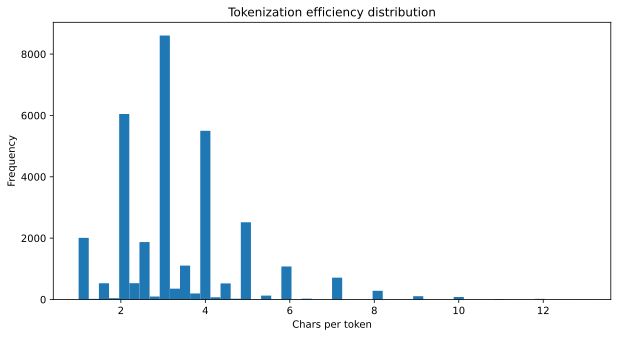

In [243]:
import matplotlib.pyplot as plt

eff_scores = []

for word in original_text:
    len_char = len(word)
    len_tokens = len(tokenizer.encode(word))
    if len_tokens > 0:
        eff_scores.append(len_char / len_tokens)

plt.figure(figsize=(10, 5))
plt.hist(eff_scores, bins=50)
plt.xlabel("Chars per token")
plt.ylabel("Frequency")
plt.title("Tokenization efficiency distribution")
plt.show()


# Token Efficiency 2

In [2]:
pip -q install tiktoken

In [13]:
import requests
import re
import tiktoken

text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tokenizer = tiktoken.get_encoding('cl100k_base')
tokenizer

<Encoding 'cl100k_base'>

In [54]:
import requests
import re
import tiktoken
import string
import numpy as np
import matplotlib.pyplot as plt

text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tokenizer = tiktoken.get_encoding('cl100k_base')

original_text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
original_text = re.split(r"\s+", original_text)
original_text = [w.lower().strip() for w in original_text]
unique_words, unique_counts = np.unique(original_text, return_counts = True)

In [55]:
# initialize results vectors
num_tokens = np.zeros(len(unique_words), dtype = int)

# loop through all unique words
for i, unique_word in enumerate(unique_words):
  num_tokens[i] = len(tokenizer.encode(unique_word))

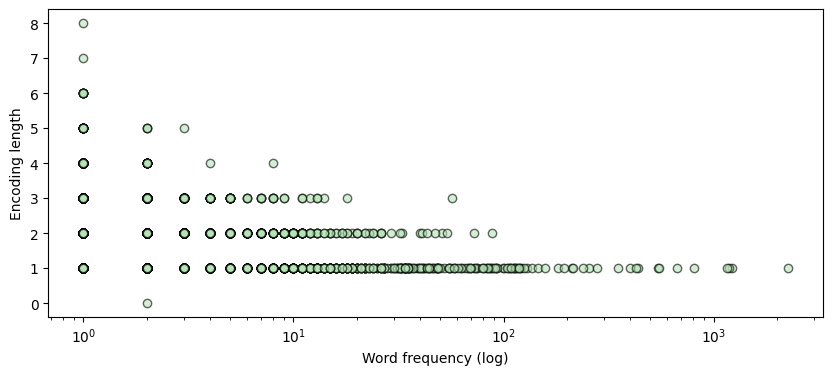

In [63]:
plt.figure(figsize = (10,4))
plt.plot(counts, num_tokens, 'ko', markerfacecolor = [.7,.9,.7], alpha = .6)
plt.gca().set(xlabel = 'Word frequency (log)', ylabel = 'Encoding length', xscale = 'log')
plt.show()

In [61]:
word_freq_idx = np.argsort(counts)[::-1]
for i in word_freq_idx[:20]:
  print(f'{word_freq[i]:>6,} appearances of "{unique_words[i]}"')

 2,769 appearances of "the"
 1,303 appearances of "and"
 8,728 appearances of "i"
 1,221 appearances of "of"
11,499 appearances of "a"
 1,183 appearances of "to"
   564 appearances of "was"
 2,902 appearances of "in"
   489 appearances of "my"
   422 appearances of "that"
 1,238 appearances of "it"
   367 appearances of "had"
 1,317 appearances of "me"
 1,221 appearances of "as"
 1,516 appearances of "at"
   239 appearances of "with"
   324 appearances of "for"
   104 appearances of "time"
   116 appearances of "but"
   163 appearances of "were"


# Fake words from real tokens

In [82]:
n_tokens = 3

# choose some random tokens
rand_tokens = np.random.choice(range(tokenizer.n_vocab), n_tokens)

# print the individual tokens
for t in rand_tokens:
  print(f'Token {t} is "{tokenizer.decode([t])}"')

# fake word without whitespace
fake_word = re.sub(r'\s+', '', tokenizer.decode(rand_tokens))

print(f'\nThe fake word is "{fake_word}"')

Token 28163 is "lett"
Token 86376 is ":mysql"
Token 50403 is "POL"

The fake word is "lett:mysqlPOL"


# How many r's in strawberry

In [83]:
!pip -q install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

Count the r's in strawberry

In [84]:
strawberry = tokenizer.encode('strawberry')
for t in strawberry:
  print(f'{t:5d} = {tokenizer.decode([t])}')

  496 = str
  675 = aw
15717 = berry


In [87]:
r = tokenizer.encode('r')
print(f'{r} = {tokenizer.decode(r)}')

[81] = r


In [88]:
r in strawberry

False

Conclusion: There are no r's in strawberry

In [89]:
strawberr_string = tokenizer.decode(strawberry)
strawberr_string

'strawberry'

In [90]:
r_string = tokenizer.decode(r)
r_string

'r'

In [91]:
strawberr_string.count(r_string)

3

# Algo rapper name

In [134]:
first_name = 'Adrian'
last_name  = 'Kazi'
fav_color  = 'black'

text = ' '.join([first_name, last_name, fav_color])
text

'Adrian Kazi black'

In [135]:
idx = tokenizer.encode(text)
idx.sort()
idx

[735, 2654, 3776, 7414, 18291]

In [136]:
def not_normal(token_str):
  pattern = re.compile(r'^[A-Za-z0-9\s]+$')
  return not bool(pattern.fullmatch(token_str))

In [137]:
# part 1: first letter of first name -1
part1 = tokenizer.encode(first_name[0])[0]-1
while not_normal(tokenizer.decode([part1])):
  part1 += 1

# part 2: last letter of the last name +1
part2 = tokenizer.encode(last_name[-1])[0]+1
while not_normal(tokenizer.decode([part2])):
  part2 += 1

# part 3: last/first + average of middle
part3 = int(idx[-1]/idx[0] + np.mean(idx[1:-1]))
while not_normal(tokenizer.decode([part3])):
  part3 += 1

In [138]:
rappername = [part1, part2, part3]
print(f'My rapper name is "{tokenizer.decode(rappername)}"')

My rapper name is "Aj teach"
